# Học bán giám sát

Trong thực tế, dữ liệu có nhãn thường rất hạn chế.

Do đó chúng ta thử nghiệm phương pháp học bán giám sát bằng thuật toán Label Spreading để tận dụng dữ liệu chưa gán nhãn.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/water_clean.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2620, 9)
Test shape: (656, 9)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def pr_auc_score_custom(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    return auc(recall, precision)

In [7]:
def run_semi_supervised_experiment(X_train_scaled, y_train, X_test_scaled, y_test, label_rate=0.2, random_state=42):
    rng = np.random.RandomState(random_state)

    y_train_array = y_train.to_numpy().copy()

    n_labeled = int(len(y_train_array) * label_rate)
    labeled_idx = rng.choice(len(y_train_array), size=n_labeled, replace=False)

    y_train_semi = np.full_like(y_train_array, fill_value=-1)
    y_train_semi[labeled_idx] = y_train_array[labeled_idx]

    # supervised-only baseline: chỉ train trên phần có nhãn
    X_labeled = X_train_scaled[labeled_idx]
    y_labeled = y_train_array[labeled_idx]

    supervised_model = LogisticRegression(max_iter=1000, random_state=random_state)
    supervised_model.fit(X_labeled, y_labeled)

    y_pred_supervised = supervised_model.predict(X_test_scaled)
    y_score_supervised = supervised_model.predict_proba(X_test_scaled)[:, 1]

    f1_supervised = f1_score(y_test, y_pred_supervised)
    pr_auc_supervised = pr_auc_score_custom(y_test, y_score_supervised)

    # semi-supervised
    semi_model = LabelSpreading(
        kernel="knn",
        n_neighbors=7,
        alpha=0.2,
        max_iter=30
    )
    semi_model.fit(X_train_scaled, y_train_semi)

    y_pred_semi = semi_model.predict(X_test_scaled)

    # LabelSpreading không luôn có predict_proba ổn như classifier thường,
    # nên lấy decision mềm từ predict_proba nếu có
    try:
        y_score_semi = semi_model.predict_proba(X_test_scaled)[:, 1]
        pr_auc_semi = pr_auc_score_custom(y_test, y_score_semi)
    except:
        pr_auc_semi = np.nan

    f1_semi = f1_score(y_test, y_pred_semi)

    return {
        "label_rate": label_rate,
        "n_labeled": n_labeled,
        "f1_supervised": f1_supervised,
        "pr_auc_supervised": pr_auc_supervised,
        "f1_semi": f1_semi,
        "pr_auc_semi": pr_auc_semi,
        "y_pred_supervised": y_pred_supervised,
        "y_pred_semi": y_pred_semi
    }

In [8]:
results = []

for rate in [0.05, 0.10, 0.20]:
    result = run_semi_supervised_experiment(
        X_train_scaled, y_train,
        X_test_scaled, y_test,
        label_rate=rate,
        random_state=42
    )
    results.append(result)

results_df = pd.DataFrame(results)[
    ["label_rate", "n_labeled", "f1_supervised", "pr_auc_supervised", "f1_semi", "pr_auc_semi"]
]

results_df

,label_rate,n_labeled,f1_supervised,pr_auc_supervised,f1_semi,pr_auc_semi
0,0.05,131,0.282776,0.413444,0.232687,0.410640
1,0.10,262,0.210826,0.387339,0.280788,0.396494
2,0.20,524,0.193146,0.418937,0.328358,0.446725


In [9]:
results_df.to_csv("../outputs/semi_supervised_results.csv", index=False)
results_df

,label_rate,n_labeled,f1_supervised,pr_auc_supervised,f1_semi,pr_auc_semi
0,0.05,131,0.282776,0.413444,0.232687,0.410640
1,0.10,262,0.210826,0.387339,0.280788,0.396494
2,0.20,524,0.193146,0.418937,0.328358,0.446725


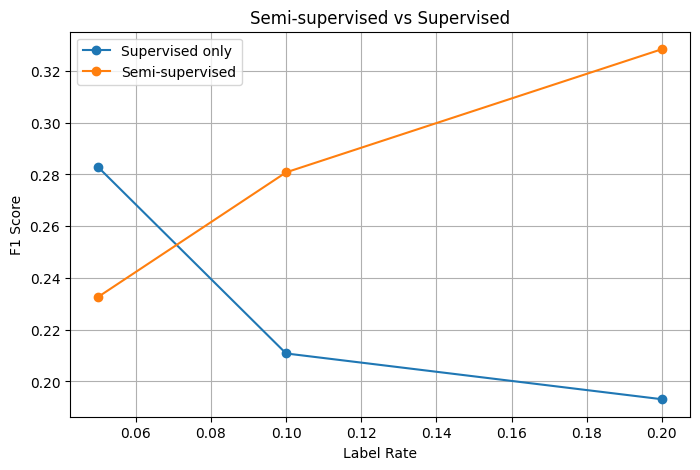

In [10]:
plt.figure(figsize=(8,5))
plt.plot(results_df["label_rate"], results_df["f1_supervised"], marker="o", label="Supervised only")
plt.plot(results_df["label_rate"], results_df["f1_semi"], marker="o", label="Semi-supervised")
plt.xlabel("Label Rate")
plt.ylabel("F1 Score")
plt.title("Semi-supervised vs Supervised")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
final_result = run_semi_supervised_experiment(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    label_rate=0.20,
    random_state=42
)

print("=== Supervised-only (20% labeled) ===")
print(classification_report(y_test, final_result["y_pred_supervised"]))

print("=== Semi-supervised (20% labeled) ===")
print(classification_report(y_test, final_result["y_pred_semi"]))

=== Supervised-only (20% labeled) ===
              precision    recall  f1-score   support

           0       0.62      0.92      0.74       400
           1       0.48      0.12      0.19       256

    accuracy                           0.61       656
   macro avg       0.55      0.52      0.47       656
weighted avg       0.56      0.61      0.53       656

=== Semi-supervised (20% labeled) ===
              precision    recall  f1-score   support

           0       0.63      0.80      0.70       400
           1       0.45      0.26      0.33       256

    accuracy                           0.59       656
   macro avg       0.54      0.53      0.52       656
weighted avg       0.56      0.59      0.56       656



Kết quả cho thấy mô hình bán giám sát giúp cải thiện hiệu quả dự đoán khi số lượng dữ liệu có nhãn bị hạn chế.

In [12]:
semi_model = LabelSpreading(
    kernel="knn",
    n_neighbors=5,
    alpha=0.2,
    max_iter=20
)